# Single-agent DDPM on ETH/UCY

This notebook reuses the toy DDPM for the standard ETH/UCY trajectory shape: 8 observed positions (3.2 s) and 12 future positions (4.8 s), sampled at 2.5 Hz. It is deliberately a single-pedestrian conditional model: social interactions and scene context are later stages.

The Social GAN-style fold directories already supply scene-disjoint `train`, `val`, and `test` partitions. Set `HELDOUT_SCENE` to reproduce one leave-one-scene-out fold. Do not inspect the test partition while choosing settings.

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'toy_diffusion').exists():
    REPO_ROOT = REPO_ROOT.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.eth_ucy.dataset import NavBenchmarkDataset
from toy_diffusion.diffusion import Diffuser
from toy_diffusion.models import Denoiser

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using {device}')

Using mps


In [2]:
# Change only these experiment settings at first.
SEED = 7
HELDOUT_SCENE = 'eth'  # one of: eth, hotel, univ, zara1, zara2
OBS_LEN, PRED_LEN = 8, 12
BATCH_SIZE = 128
NUM_DIFFUSION_STEPS = 100
LEARNING_RATE = 1e-3
EPOCHS = 100
NUM_SAMPLES = 20

RUN_TRAINING = True
RUN_TEST_EVALUATION = True  # turn on only after selecting settings with validation

random.seed(SEED)
torch.manual_seed(SEED)
if device.type == 'mps':
    torch.mps.manual_seed(SEED)

In [3]:
train_set = NavBenchmarkDataset('train', HELDOUT_SCENE, OBS_LEN, PRED_LEN)
val_set = NavBenchmarkDataset('val', HELDOUT_SCENE, OBS_LEN, PRED_LEN)
test_set = NavBenchmarkDataset('test', HELDOUT_SCENE, OBS_LEN, PRED_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'{HELDOUT_SCENE=}: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}')
past, future, file_id, frame_start, pedestrian_id = train_set[0]
print(f'Example: {train_set.file_name(file_id.item())}, frame {frame_start.item()}, pedestrian {pedestrian_id.item()}')
print(f'{past.shape=}, {future.shape=}')

HELDOUT_SCENE='eth': train=30307, val=5422, test=364
Example: biwi_hotel_train, frame 0, pedestrian 5
past.shape=torch.Size([8, 2]), future.shape=torch.Size([12, 2])


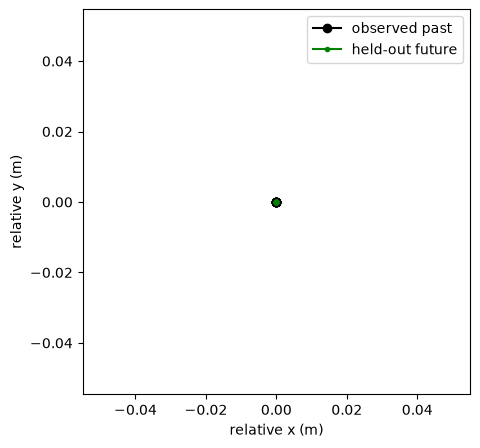

In [4]:
# All coordinates are relative to the last observed point, shown as the black dot.
plt.figure(figsize=(5, 5))
plt.plot(past[:, 0], past[:, 1], 'ko-', label='observed past')
plt.plot(torch.cat([past[-1:, 0], future[:, 0]]), torch.cat([past[-1:, 1], future[:, 1]]), 'g.-', label='held-out future')
plt.axis('equal')
plt.xlabel('relative x (m)')
plt.ylabel('relative y (m)')
plt.legend()
plt.show()

## Metrics and constant-velocity reference

ADE is the mean Euclidean position error over all 12 future timestamps. FDE is the Euclidean error only at the final (4.8 s) timestamp. Both are in meters. The constant-velocity baseline is a useful sanity check, not a target to optimize against.

In [5]:
def ade_fde(prediction, target):
    """Returns one ADE and FDE per item for [B, T, 2] tensors."""
    point_errors = torch.linalg.vector_norm(prediction - target, dim=-1)
    return point_errors.mean(dim=-1), point_errors[:, -1]

def constant_velocity(past):
    velocity = past[:, -1] - past[:, -2]
    steps = torch.arange(1, PRED_LEN + 1, device=past.device).view(1, -1, 1)
    return past[:, -1:].add(steps * velocity.unsqueeze(1))

@torch.no_grad()
def evaluate_deterministic(loader, predictor):
    all_ade, all_fde = [], []
    for past, future, *_ in loader:
        prediction = predictor(past.to(device))
        ade, fde = ade_fde(prediction.cpu(), future)
        all_ade.append(ade)
        all_fde.append(fde)
    return torch.cat(all_ade).mean().item(), torch.cat(all_fde).mean().item()

val_cv_ade, val_cv_fde = evaluate_deterministic(val_loader, constant_velocity)
print(f'Validation constant-velocity: ADE={val_cv_ade:.3f} m, FDE={val_cv_fde:.3f} m')

Validation constant-velocity: ADE=0.447 m, FDE=0.988 m


In [6]:
model = Denoiser(
    obs_len=OBS_LEN,
    pred_len=PRED_LEN,
    coordinate_dim=2,
).to(device)
diffuser = Diffuser(NUM_DIFFUSION_STEPS).to(device)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()
print(f'Parameters: {sum(parameter.numel() for parameter in model.parameters()):,}')

Parameters: 29,870


In [7]:
def run_epsilon_epoch(loader, training):
    model.train(training)
    losses, ades, fdes = [], [], []
    with torch.set_grad_enabled(training):
        for past, future, *_ in loader:
            past_flat = past.flatten(start_dim=1).to(device)
            future_flat = future.flatten(start_dim=1).to(device)
            epsilon = torch.randn_like(future_flat)
            timesteps = torch.randint(0, diffuser.num_diffusion_steps, (len(past),), device=device)
            x_t, _ = diffuser.add_noise(future_flat, timesteps, epsilon)
            epsilon_pred = model(x_t, past_flat, timesteps)
            loss = loss_fn(epsilon_pred, epsilon)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            losses.append(loss.detach().cpu())

            # Diagnostic only: recover x0 from this known x_t in one algebraic step.
            x0_estimate = diffuser.predict_x0(x_t, timesteps, epsilon_pred)
            ade, fde = ade_fde(x0_estimate.view(-1, PRED_LEN, 2).cpu(), future)
            ades.append(ade)
            fdes.append(fde)
    return torch.stack(losses).mean().item(), torch.cat(ades).mean().item(), torch.cat(fdes).mean().item()

history = {'train_loss': [], 'val_loss': [], 'val_ade': [], 'val_fde': []}
if RUN_TRAINING:
    for epoch in range(1, EPOCHS + 1):
        train_loss, _, _ = run_epsilon_epoch(train_loader, training=True)
        val_loss, val_ade, val_fde = run_epsilon_epoch(val_loader, training=False)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_ade'].append(val_ade)
        history['val_fde'].append(val_fde)
        if epoch == 1 or epoch % 10 == 0:
            print(f'{epoch:03d}: train MSE={train_loss:.4f}, val MSE={val_loss:.4f}, val ADE={val_ade:.3f}, val FDE={val_fde:.3f}')

    output_dir = REPO_ROOT / 'experiments' / 'eth_ucy' / 'outputs'
    output_dir.mkdir(exist_ok=True)
    torch.save(model.state_dict(), output_dir / f'single_agent_ddpm_{HELDOUT_SCENE}.pt')

001: train MSE=0.5854, val MSE=0.3232, val ADE=0.306, val FDE=0.450
010: train MSE=0.1845, val MSE=0.1824, val ADE=0.228, val FDE=0.393
020: train MSE=0.1662, val MSE=0.1636, val ADE=0.216, val FDE=0.376
030: train MSE=0.1577, val MSE=0.1553, val ADE=0.211, val FDE=0.376
040: train MSE=0.1550, val MSE=0.1498, val ADE=0.201, val FDE=0.362
050: train MSE=0.1519, val MSE=0.1482, val ADE=0.197, val FDE=0.352
060: train MSE=0.1477, val MSE=0.1477, val ADE=0.202, val FDE=0.369
070: train MSE=0.1474, val MSE=0.1463, val ADE=0.194, val FDE=0.344
080: train MSE=0.1465, val MSE=0.1424, val ADE=0.192, val FDE=0.344
090: train MSE=0.1446, val MSE=0.1481, val ADE=0.200, val FDE=0.361
100: train MSE=0.1453, val MSE=0.1469, val ADE=0.190, val FDE=0.335


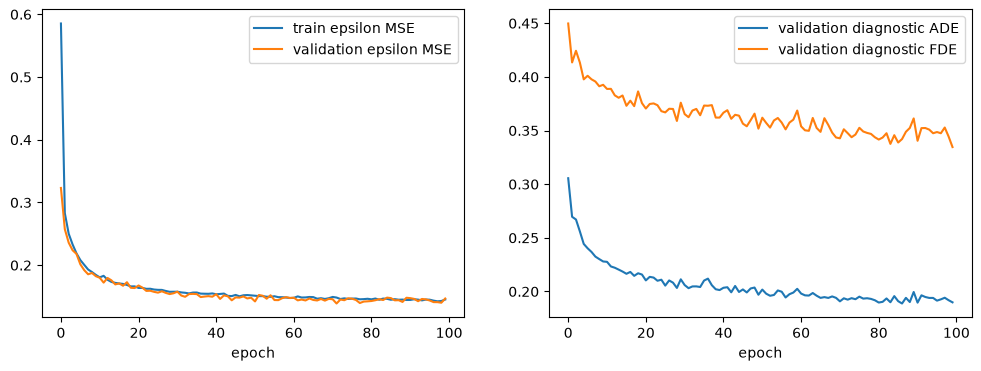

In [8]:
if history['train_loss']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train epsilon MSE')
    axes[0].plot(history['val_loss'], label='validation epsilon MSE')
    axes[0].legend(); axes[0].set_xlabel('epoch')
    axes[1].plot(history['val_ade'], label='validation diagnostic ADE')
    axes[1].plot(history['val_fde'], label='validation diagnostic FDE')
    axes[1].legend(); axes[1].set_xlabel('epoch')
    plt.show()

## Reverse diffusion and multimodal evaluation

The training diagnostic above is not a sampled forecast: it starts from a known noisy version of the answer. The functions below perform the actual reverse process from Gaussian noise. A diffusion model can produce several plausible futures for one past, so `best-of-K` reports the closest of `K` independently sampled trajectories to the recorded future. Report `K` whenever comparing results.

In [9]:
@torch.no_grad()
def sample_futures(past, num_samples=NUM_SAMPLES):
    """Returns [B, K, pred_len, 2] ancestral DDPM samples."""
    model.eval()
    batch_size = len(past)
    past_repeated = past.to(device).flatten(start_dim=1).repeat_interleave(num_samples, dim=0)
    x_t = torch.randn(batch_size * num_samples, model.future_dim, device=device)
    for timestep in reversed(range(diffuser.num_diffusion_steps)):
        timesteps = torch.full((len(x_t),), timestep, device=device, dtype=torch.long)
        epsilon_pred = model(x_t, past_repeated, timesteps)
        x_t = diffuser.denoise_step(x_t, timestep, epsilon_pred)
    return x_t.view(batch_size, num_samples, PRED_LEN, 2).cpu()

@torch.no_grad()
def evaluate_best_of_k(loader, num_samples=NUM_SAMPLES):
    best_ades, best_fdes = [], []
    for past, future, *_ in loader:
        samples = sample_futures(past, num_samples)
        point_errors = torch.linalg.vector_norm(samples - future[:, None], dim=-1)
        best_ades.append(point_errors.mean(dim=-1).min(dim=1).values)
        best_fdes.append(point_errors[:, :, -1].min(dim=1).values)
    return torch.cat(best_ades).mean().item(), torch.cat(best_fdes).mean().item()

if RUN_TEST_EVALUATION:
    test_ade, test_fde = evaluate_best_of_k(test_loader)
    print(f'Test best-of-{NUM_SAMPLES}: ADE={test_ade:.3f} m, FDE={test_fde:.3f} m')

Test best-of-20: ADE=1.351 m, FDE=2.497 m


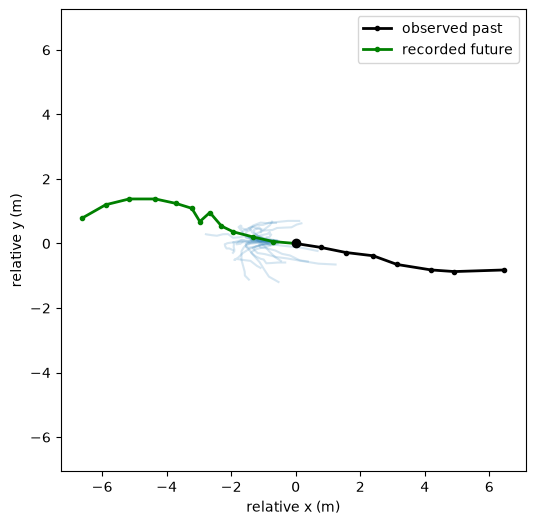

In [10]:
# Visualize multiple sampled futures for one held-out trajectory after training.
example_past, example_future, *_ = test_set[0]
samples = sample_futures(example_past.unsqueeze(0), num_samples=20)[0]
plt.figure(figsize=(6, 6))
for sample in samples:
    plt.plot(sample[:, 0], sample[:, 1], color='tab:blue', alpha=0.18)
plt.plot(example_past[:, 0], example_past[:, 1], 'k.-', linewidth=2, label='observed past')
plt.plot(torch.cat([example_past[-1:, 0], example_future[:, 0]]), torch.cat([example_past[-1:, 1], example_future[:, 1]]), 'g.-', linewidth=2, label='recorded future')
plt.scatter([0], [0], c='black', zorder=3)
plt.axis('equal'); plt.xlabel('relative x (m)'); plt.ylabel('relative y (m)')
plt.legend(); plt.show()

## All-fold baseline sweep

This opt-in runner trains a fresh single-agent DDPM for every leave-one-scene-out fold. It selects the checkpoint with the lowest validation epsilon MSE, then evaluates that checkpoint once on the fold's test partition. The resulting CSV is a baseline comparison artifact, not a paper-level result.

In [ ]:
ALL_FOLDS = ('eth', 'hotel', 'univ', 'zara1', 'zara2')
RUN_ALL_FOLDS = False
ALL_FOLDS_EPOCHS = EPOCHS
ALL_FOLDS_BATCH_SIZE = BATCH_SIZE
ALL_FOLDS_NUM_SAMPLES = NUM_SAMPLES

def set_experiment_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if device.type == 'mps':
        torch.mps.manual_seed(seed)

def run_epsilon_epoch_for(model, diffuser, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, total_examples = 0.0, 0
    with torch.set_grad_enabled(training):
        for past, future, *_ in loader:
            past_flat = past.flatten(start_dim=1).to(device)
            future_flat = future.flatten(start_dim=1).to(device)
            epsilon = torch.randn_like(future_flat)
            timesteps = torch.randint(0, diffuser.num_diffusion_steps, (len(past),), device=device)
            x_t, _ = diffuser.add_noise(future_flat, timesteps, epsilon)
            loss = nn.functional.mse_loss(model(x_t, past_flat, timesteps), epsilon)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.detach().item() * len(past)
            total_examples += len(past)
    return total_loss / total_examples

@torch.no_grad()
def sample_futures_for(model, diffuser, past, num_samples):
    model.eval()
    batch_size = len(past)
    context = past.to(device).flatten(start_dim=1).repeat_interleave(num_samples, dim=0)
    x_t = torch.randn(batch_size * num_samples, model.future_dim, device=device)
    for timestep in reversed(range(diffuser.num_diffusion_steps)):
        timesteps = torch.full((len(x_t),), timestep, device=device, dtype=torch.long)
        x_t = diffuser.denoise_step(x_t, timestep, model(x_t, context, timesteps))
    return x_t.view(batch_size, num_samples, PRED_LEN, 2).cpu()

@torch.no_grad()
def evaluate_best_of_k_for(model, diffuser, loader, num_samples):
    best_ades, best_fdes = [], []
    for past, future, *_ in loader:
        samples = sample_futures_for(model, diffuser, past, num_samples)
        point_errors = torch.linalg.vector_norm(samples - future[:, None], dim=-1)
        best_ades.append(point_errors.mean(dim=-1).min(dim=1).values)
        best_fdes.append(point_errors[:, :, -1].min(dim=1).values)
    return torch.cat(best_ades).mean().item(), torch.cat(best_fdes).mean().item()

def train_and_evaluate_fold(heldout_scene):
    set_experiment_seed(SEED)
    train_data = NavBenchmarkDataset('train', heldout_scene, OBS_LEN, PRED_LEN)
    val_data = NavBenchmarkDataset('val', heldout_scene, OBS_LEN, PRED_LEN)
    test_data = NavBenchmarkDataset('test', heldout_scene, OBS_LEN, PRED_LEN)
    train_data_loader = DataLoader(train_data, batch_size=ALL_FOLDS_BATCH_SIZE, shuffle=True, num_workers=0)
    val_data_loader = DataLoader(val_data, batch_size=ALL_FOLDS_BATCH_SIZE, shuffle=False, num_workers=0)
    test_data_loader = DataLoader(test_data, batch_size=ALL_FOLDS_BATCH_SIZE, shuffle=False, num_workers=0)
    fold_model = Denoiser(obs_len=OBS_LEN, pred_len=PRED_LEN, coordinate_dim=2).to(device)
    fold_diffuser = Diffuser(NUM_DIFFUSION_STEPS).to(device)
    fold_optimizer = Adam(fold_model.parameters(), lr=LEARNING_RATE)
    best_val_loss, best_state = float('inf'), None
    for epoch in range(1, ALL_FOLDS_EPOCHS + 1):
        train_loss = run_epsilon_epoch_for(fold_model, fold_diffuser, train_data_loader, fold_optimizer)
        val_loss = run_epsilon_epoch_for(fold_model, fold_diffuser, val_data_loader)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {name: value.detach().cpu().clone() for name, value in fold_model.state_dict().items()}
        if epoch == 1 or epoch % 10 == 0:
            print(f'{heldout_scene} {epoch:03d}: train MSE={train_loss:.4f}, val MSE={val_loss:.4f}')
    fold_model.load_state_dict(best_state)

    # The test partition is touched only after validation checkpoint selection.
    cv_ade, cv_fde = evaluate_deterministic(test_data_loader, constant_velocity)
    ddpm_ade, ddpm_fde = evaluate_best_of_k_for(fold_model, fold_diffuser, test_data_loader, ALL_FOLDS_NUM_SAMPLES)
    output_dir = REPO_ROOT / 'experiments' / 'eth_ucy' / 'outputs'
    output_dir.mkdir(exist_ok=True)
    torch.save({'model_state_dict': fold_model.state_dict(), 'diffuser_state_dict': fold_diffuser.state_dict()}, output_dir / f'single_agent_ddpm_{heldout_scene}.pt')
    return {
        'heldout_scene': heldout_scene,
        'best_validation_epsilon_mse': best_val_loss,
        'constant_velocity_test_ade_m': cv_ade,
        'constant_velocity_test_fde_m': cv_fde,
        f'ddpm_best_of_{ALL_FOLDS_NUM_SAMPLES}_test_ade_m': ddpm_ade,
        f'ddpm_best_of_{ALL_FOLDS_NUM_SAMPLES}_test_fde_m': ddpm_fde,
    }

if RUN_ALL_FOLDS:
    all_fold_results = [train_and_evaluate_fold(scene) for scene in ALL_FOLDS]

In [ ]:
if RUN_ALL_FOLDS:
    import pandas as pd

    all_fold_results_table = pd.DataFrame(all_fold_results).set_index('heldout_scene')
    display(all_fold_results_table.round(3))
    all_fold_results_table.to_csv(REPO_ROOT / 'experiments' / 'eth_ucy' / 'outputs' / 'single_agent_ddpm_all_folds.csv')

    metric_columns = [column for column in all_fold_results_table.columns if column.endswith(('_ade_m', '_fde_m'))]
    all_fold_results_table[metric_columns].plot.bar(figsize=(12, 5), ylabel='metres', rot=0)
    plt.title(f'Single-agent DDPM vs. constant velocity (best-of-{ALL_FOLDS_NUM_SAMPLES})')
    plt.tight_layout()
    plt.show()